In [1]:
from google import genai
import os

client = genai.Client(api_key=os.environ.get("GEMINI_API_KEY"))

response = client.models.generate_content(
    model="gemini-3.1-pro-preview", 
    contents="Hello from my Jupyter notebook!"
)

print(response.text)

Hello! 👋 It's great to connect right from your Jupyter environment. 

What are we working on today? Whether you're exploring some data, training a machine learning model, debugging Python code, or creating visualizations, I'm here to help. 

Let me know what you need!


In [3]:
import sys
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Torch CUDA:", torch.version.cuda)

Torch version: 2.2.0+cu118
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
Torch CUDA: 11.8


In [18]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
import requests
import pandas as pd
import re
from jiwer import wer, cer

## Download Dataset

In [14]:
import os

data_dir = "../test_img"

pages = [
    78,
    94,

]

for p in pages:
    image_path = os.path.join(data_dir, f"{p}.jpg")
    print(image_path, ":", os.path.exists(image_path))

../test_img\78.jpg : True
../test_img\94.jpg : True


In [15]:
import os

output_dir = "Output_improvement/experiment_files"
os.makedirs(output_dir, exist_ok=True)

output_dir_2 = "Output_improvement/experiment_graphs"
os.makedirs(output_dir_2, exist_ok=True)

## Prompt

In [6]:
#7.9% wer 
prompt_78 = """
You are an OCR specialist.

Transcribe every visible character on this page exactly as printed.

Follow this page-specific reading order:

1. Read the top header and the short continuation text below it.
2. Continue with the section heading, item heading, source information, and the main single-column text from top to bottom.
3. Include all marginal line numbers, dates, page number, bracketed dates, footnote markers, and superscript numbers.
4. At the bottom two-column footnote section, read the entire left column from top to bottom first, then the entire right column from 
top to bottom. Do not alternate between the two columns line by line.

Preserve the original German and Latin spelling, punctuation, capitalization, abbreviations, special characters, and line-ending hyphenation. 
Do not correct, modernize, translate, summarize, or infer missing text.

Avoid hallucination. Do not invent, reconstruct, complete, or guess any character, word, number, or passage that is unclear
or not visibly present in the image. If text cannot be read reliably, use [illegible] instead of guessing.

Return only the transcription.

"""

In [7]:
# 5.3% wer  1.8% cer
prompt_78_2 = """You are an OCR specialist.

Transcribe every visible character on this page exactly as printed.

Follow this page-specific reading order:

1. Read the top header and the short continuation text below it.
2. Continue with the section heading, item heading, source information, and the main single-column text from top to bottom.
3. Include all marginal line numbers, dates, page number, bracketed dates, footnote markers, and superscript numbers.
4. Do not insert marginal information into the middle of running sentences. When dates, line numbers, page references, 
or other annotations appear beside the main text,
first transcribe the complete corresponding main text block in its normal reading order.
Then transcribe the marginal information separately in top-to-bottom order before continuing to the next text block.
5. At the bottom two-column footnote section, read the entire left column from top to bottom first, then the entire right column 
from top to bottom. Do not alternate between the two columns line by line.

Preserve the original German and Latin spelling, punctuation, capitalization, abbreviations, special characters, and line-ending hyphenation.
Do not correct, modernize, translate, summarize, or infer missing text.

Avoid hallucination. Do not invent, reconstruct, complete, or guess any character, word, number, or passage that is unclear
or not visibly present in the image. If text cannot be read reliably, use [illegible] instead of guessing.

Return only the transcription.
"""

In [8]:
prompt_94 = """
You are an OCR specialist.

Transcribe every visible character exactly as printed.

For this page, follow this reading order:
1. Transcribe the left-margin line numbers first, from top to bottom.
2. Then transcribe the complete main text from top to bottom, including sections 44, 45, and 46.
3. At the bottom two-column footnote section, read the entire left column first, then the entire right column.
4. Transcribe the right-margin dates and annotations last, from top to bottom.

Preserve the original spelling, punctuation, numbers, abbreviations, special characters, and hyphenation. Do not correct, modernize, translate, summarize, or guess unclear text.

Return only the transcription.
"""

In [9]:
# 12.5% wer
prompt_94_2 = """
You are an OCR specialist.

Transcribe the page exactly as printed.

Reading order:
1. Left-margin line numbers first, from top to bottom.
2. Main text from top to bottom, including sections 44, 45, and 46.
3. Bottom footnotes: complete left column first, then complete right column.
4. Right-margin annotations last, from top to bottom.

Within each text block, preserve the printed line order. Do not rearrange, correct, modernize, or normalize historical words, abbreviations, numbers, or characters.

Return only the transcription.
"""

In [10]:
prompts = {
    78: prompt_78_2,
    94: prompt_94_2,
}

In [11]:
import os
from google import genai
from google.genai import types


def run_ocr_one_image(image_path, prompt_text):
    with open(image_path, "rb") as f:
        image_bytes = f.read()

    response = client.models.generate_content(
        model="gemini-3.1-pro-preview",
        contents=[
            prompt_text,
            types.Part.from_bytes(
                data=image_bytes,
                mime_type="image/jpeg"
            )
        ]
    )

    return response.text

In [15]:
run_number = 4

In [175]:
for p in pages:
    print(f"\n==============================")
    print(f"Page {p}")
    print(f"Run {run_number}")
    print(f"==============================")

    image_path = os.path.join(data_dir, f"{p}.jpg")

    output_path = os.path.join(
        output_dir,
        f"{p}_run_{run_number}.txt"
    )

    output_text = run_ocr_one_image(
        image_path,
        prompts[p]
    )

    print(output_text)

    with open(output_path, "w", encoding="utf-8") as f:
        f.write(output_text)

    print(f"Saved: {output_path}")


Page 94
Run 4
5
10
15
20
25
30
35
40
A. Vermittlungstag zu Speier-Heidelberg im Mai 1406 nr. 32-48.                                                                                                                83
44. Gf. Philipp I von Nassau tritt in den Marbacher Bund ein. [1406 Mai 16
Speier.]
W aus Wirzburg Kr.-A. Mainz-Aschaffenb. Ingross.-B. 14 fol. 143a cop. ch. coaev., mit
der Überschrift Als sich min herre grave Philips den herren und steten widderumbe
verschriben hait etc.
ABC coll. die Beitrittsurkunde von Worms nr. 46, s. Quellenangabe dort.
Wir Philips grave zu Nassawe und Sarbrucken bekennen [u. s. w.]: [mut. mut. wie in der Revers-
urkunde nr. 43] als genannte fünf Theile sich zu Marbach zu näher ausgeführten Zwecken vereiniget haben
bis zum vergangenen unser Frauen Tag purif. über 5 Jahre, wie die Vereinigungsbriefe ausweisen: daz
wir in dieselben einunge unsers obgenanten herren von Mencze teile auch kommen sin und daz uns
derselbe unser lieber herre und auch die ande

In [12]:
def normalize_text(text):
    text = text.lower()
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    return text

In [19]:
run_number = 4

results_exp1 = []

gold_base = "https://nlp.fi.muni.cz/projekty/ahisto/ocr-output/494/"

for p in pages:
    print(f"Evaluating page {p}, run {run_number}...")

    gold_url = f"{gold_base}{p}.txt"
    gold_text = requests.get(gold_url).text

    pred_path = os.path.join(
        output_dir,
        f"{p}_run_{run_number}.txt"
    )

    with open(pred_path, "r", encoding="utf-8") as f:
        pred_text = f.read()

    gold_norm = normalize_text(gold_text)
    pred_norm = normalize_text(pred_text)

    wer_score = wer(gold_norm, pred_norm)
    cer_score = cer(gold_norm, pred_norm)

    results_exp1.append({
        "page": p,
        "WER": wer_score,
        "CER": cer_score
    })

Evaluating page 78, run 4...
Evaluating page 94, run 4...


In [20]:
print("=== Recognition Improvement Results: Gemini 3.1 Pro ===")

df_exp1 = pd.DataFrame(results_exp1)
df_exp1

=== Recognition Improvement Results: Gemini 3.1 Pro ===


,page,WER,CER
0,78,0.053237,0.018138
1,94,0.124579,0.039459


### All together

In [21]:
results_runs = []

gold_base = "https://nlp.fi.muni.cz/projekty/ahisto/ocr-output/494/"

pages = [78, 94]
runs = [1, 2, 3, 4]

for p in pages:

    gold_url = f"{gold_base}{p}.txt"
    gold_text = requests.get(gold_url).text
    gold_norm = normalize_text(gold_text)

    for run_number in runs:
        print(f"Evaluating Page {p} - Run {run_number}...")

        pred_path = os.path.join(
            output_dir,
            f"{p}_run_{run_number}.txt"
        )

        with open(pred_path, "r", encoding="utf-8") as f:
            pred_text = f.read()

        pred_norm = normalize_text(pred_text)

        wer_score = wer(gold_norm, pred_norm)
        cer_score = cer(gold_norm, pred_norm)

        results_runs.append({
            "page": p,
            "run": run_number,
            "WER": wer_score,
            "CER": cer_score
        })

print("Evaluation complete.")

Evaluating Page 78 - Run 1...
Evaluating Page 78 - Run 2...
Evaluating Page 78 - Run 3...
Evaluating Page 78 - Run 4...
Evaluating Page 94 - Run 1...
Evaluating Page 94 - Run 2...
Evaluating Page 94 - Run 3...
Evaluating Page 94 - Run 4...
Evaluation complete.


In [22]:
df_runs = pd.DataFrame(results_runs)

df_runs["WER (%)"] = df_runs["WER"] * 100
df_runs["CER (%)"] = df_runs["CER"] * 100

df_runs

,page,run,WER,CER,WER (%),CER (%)
0,78,1,0.073381,0.034099,7.338129,3.409915
1,78,2,0.074820,0.031681,7.482014,3.168077
2,78,3,0.058993,0.019589,5.899281,1.958888
3,78,4,0.053237,0.018138,5.323741,1.813785
4,94,1,0.212121,0.094595,21.212121,9.459459
5,94,2,0.139731,0.042162,13.973064,4.216216
6,94,3,0.139731,0.041622,13.973064,4.162162
7,94,4,0.124579,0.039459,12.457912,3.945946


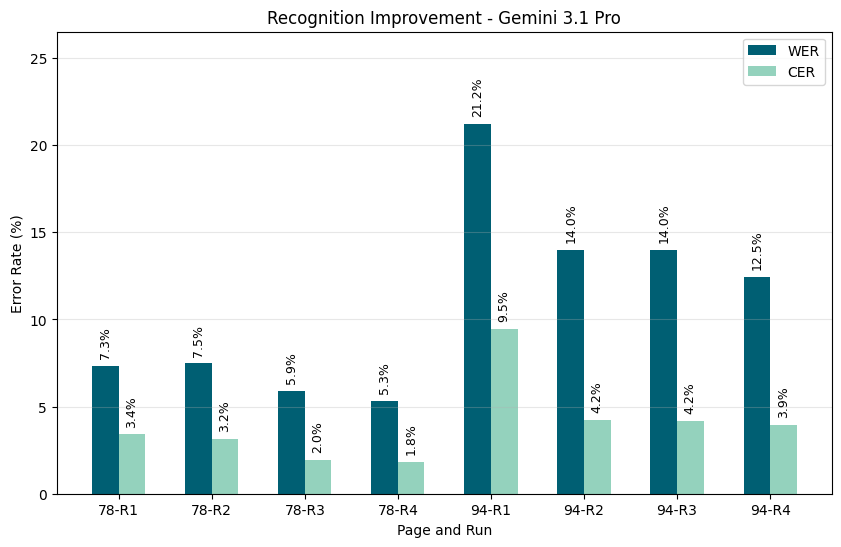

In [24]:
# With vector graphics
import numpy as np
import matplotlib.pyplot as plt
import os

# Create labels: 78-R1, 78-R2, ..., 94-R4
labels = [
    f"{int(row['page'])}-R{int(row['run'])}"
    for _, row in df_runs.iterrows()
]

# Reduce spacing between groups
x = np.arange(len(df_runs)) * 0.7

# Width of individual bars
width = 0.20

wer_pct = df_runs["WER"] * 100
cer_pct = df_runs["CER"] * 100

plt.figure(figsize=(10, 6))

# WER bars
bars1 = plt.bar(
    x - width/2,
    wer_pct,
    width,
    label="WER",
    color="#005F73" 
)

# CER bars
bars2 = plt.bar(
    x + width/2,
    cer_pct,
    width,
    label="CER",
    color="#94D2BD"
)

# Dynamic label distance
max_value = max(wer_pct.max(), cer_pct.max())
label_offset = max(max_value * 0.02, 0.05)

# WER values
for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + label_offset,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

# CER values
for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + label_offset,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

plt.xticks(x, labels)

plt.xlabel("Page and Run")
plt.ylabel("Error Rate (%)")
plt.title("Recognition Improvement - Gemini 3.1 Pro")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.ylim(0, max_value * 1.25)

os.makedirs(output_dir_2, exist_ok=True)

plt.savefig(
    os.path.join(
        output_dir_2,
        "recognition_improvement_all_runs_Gemini_3.1_Pro.pdf"
    ),
    bbox_inches="tight"
)

plt.show()

## Normalization Checking

In [189]:
p = 78
run_number = 4


gold_url = f"https://nlp.fi.muni.cz/projekty/ahisto/ocr-output/494/{p}.txt"
gold_text = requests.get(gold_url).text

pred_path = os.path.join(output_dir, f"{p}_run_{run_number}.txt")

with open(pred_path, "r", encoding="utf-8") as f:
    pred_text = f.read()

gold_norm = normalize_text(gold_text)
pred_norm = normalize_text(pred_text)

print("=== NORMALIZED GROUND TRUTH ===")
print(gold_norm)

print("\n=== NORMALIZED OCR OUTPUT ===")
print(pred_norm)

=== NORMALIZED GROUND TRUTH ===
l. vierter anhang: verhältnis k. wenzels zum marbacher bunde nr. 31. 67 sachen von des bundes wegen, den sie mit dem herzogen von orliens getan hant 1, und auch andere sache der in dann not dûnket sin mitsampt uwer sachen und uwere sachen mitsampt sinen sachen daselbs furzünemen und zû handeln. scriptum philippi et jacobi anno 400 sexto. 1406 мai 1 1406 mai 1 5 l. vierter anhang: verhältnis k. wenzels zum marbacher bunde nr. 31. 31. k. wenzel macht dem grafen eberhard von wirtemberg gewisse versprechungen, 11406 vor spt. 29] um ihn gegen k. ruprecht zu gewinnen. [1406 vor sept. 292 o. o.] 10 aus stuttgart kgl. bibl. ms. hist. 587 oswald gabelkover würtemb. gesch. 2, 254-256 sub anno 1406. regest steinhofer 2, 602-603; darnach erwähnt sattler 2, 43 und stälin 3, 387. und demnach wenceslaus der könig in “ böheim kaiser caroli iv sohn allgemach anfieng in sich selber zu gehn und zu betrachten, von was herrlichaiten und würden er durch die entsezung der chur

## RealESRGAN Preprocessed Test

In [16]:
realesrgan_images = {
    78: "Output_improvement/preprocessed_images/78_realesrgan.jpg",
    94: "Output_improvement/preprocessed_images/94_realesrgan.jpg"
}

for p, image_path in realesrgan_images.items():

    print(f"\n==============================")
    print(f"Real-ESRGAN Page {p}")
    print(f"==============================")

    output_text = run_ocr_one_image(
        image_path,
        prompts[p]
    )

    print(output_text)

    output_path = os.path.join(
        output_dir,
        f"{p}_realesrgan.txt"
    )

    with open(output_path, "w", encoding="utf-8") as f:
        f.write(output_text)

    print(f"Saved: {output_path}")


Real-ESRGAN Page 78
L. Vierter Anhang: Verhältnis K. Wenzels zum Marbacher Bunde nr. 31.          67

sachen von des bundes wegen, den sie mit dem herzogen von Orliens getan hant ^1, und
auch andere sache der in dann not dûnket sin mitsampt uwer sachen und uwere sachen
mitsampt sinen sachen daselbs furzûnemen und zû handeln.
Scriptum Philippi et Jacobi anno 400 sexto.
1406
Mai 1
1406
Mai 1

L. Vierter Anhang: Verhältnis K. Wenzels zum Marbacher Bunde nr. 31.

31. K. Wenzel macht dem Grafen Eberhard von Wirtemberg gewisse Versprechungen,
um ihn gegen K. Ruprecht zu gewinnen. [1406 vor Sept. 29 ^2 o. O.]

Aus Stuttgart Kgl. Bibl. Ms. hist. 587 Oswald Gabelkover Würtemb. Gesch. 2, 254-256
sub anno 1406.
Regest Steinhofer 2, 602-603; darnach erwähnt Sattler 2, 43 und Stälin 3, 387.
5
[1406
vor
Spt. 29]
10

Und demnach Wenceslaus der könig in ^a Böheim kaiser Caroli IV sohn allgemach
anfieng in sich selber zu gehn und zu betrachten, von was herrlichaiten und würden
er durch die entsezung d

In [20]:
results_realesrgan = []

gold_base = "https://nlp.fi.muni.cz/projekty/ahisto/ocr-output/494/"

for p in [78, 94]:
    print(f"Evaluating Real-ESRGAN page {p}...")

    gold_url = f"{gold_base}{p}.txt"
    gold_text = requests.get(gold_url).text

    pred_path = os.path.join(
        output_dir,
        f"{p}_realesrgan.txt"
    )

    with open(pred_path, "r", encoding="utf-8") as f:
        pred_text = f.read()

    gold_norm = normalize_text(gold_text)
    pred_norm = normalize_text(pred_text)

    wer_score = wer(gold_norm, pred_norm)
    cer_score = cer(gold_norm, pred_norm)

    results_realesrgan.append({
        "page": p,
        "WER": wer_score,
        "CER": cer_score
    })

    print(
        f"Page {p}: "
        f"WER = {wer_score * 100:.1f}%, "
        f"CER = {cer_score * 100:.1f}%"
    )

Evaluating Real-ESRGAN page 78...
Page 78: WER = 5.3%, CER = 2.0%
Evaluating Real-ESRGAN page 94...
Page 94: WER = 14.0%, CER = 4.2%


In [22]:
df_realesrgan = pd.DataFrame(results_realesrgan)

df_realesrgan

,page,WER,CER
0,78,0.053237,0.020073
1,94,0.139731,0.041622
